In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Reading in Data and establishing Multi Indices

In [2]:
md = pd.read_excel("250813 Merge Data.xlsx")
samplesAndBlank = md.columns.tolist()[2:]
samples = samplesAndBlank[1:]  # Exclude the first three columns which are not samples
md_multi = md.set_index('foldTrial') 
data = md_multi.pivot(columns='fluor', values=samplesAndBlank)
data.head()

Blank             0_0 L                  5_0                  6_0  \
fluor      A488   Cy3  Cy5   A488    Cy3    Cy5   A488    Cy3    Cy5   A488   
foldTrial                                                                     
1          1993  1638  377  42299  43800  45511  40773  41043  36567  41844   
2          2272  1726  370  42764  42223  44110  42768  41663  39029  43137   
3          1973  1619  355  43040  41717  43293  44200  40386  37421  42442   

           ...   0_10   0_11                 0_12                 0_15         \
fluor      ...    Cy5   A488    Cy3    Cy5   A488    Cy3    Cy5   A488    Cy3   
foldTrial  ...                                                                  
1          ...  40479  42173  21533  39618  40346  21023  39213  41726  22199   
2          ...  40715  41405  20696  39912  44131  21495  42215  42648  21310   
3          ...  42365  43930  21590  42057  44209  21115  41877  43384  22109   

                  
fluor        Cy5  
foldTrial         
1          40143  
2          41333  
3          41140  

[3 rows x 63 columns]

## Subtracting Average Blank by fluorophore

In [3]:
idx = pd.IndexSlice
fluors = ['A488', 'Cy3', 'Cy5']
blankData = data.loc[:, idx[samples, :]]
for fluor in fluors:
    avgBlank = data.loc[:, idx[['Blank'], fluor]].mean(axis=None)
    blankData.loc[:, idx[:, fluor]] -= avgBlank
    # print(fluor)
blankData.head()

C:\Users\viper\AppData\Local\Temp\ipykernel_36300\2162435964.py:6: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[40219.66666667 40684.66666667 40960.66666667]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  blankData.loc[:, idx[:, fluor]] -= avgBlank
C:\Users\viper\AppData\Local\Temp\ipykernel_36300\2162435964.py:6: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[38693.66666667 40688.66666667 42120.66666667]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  blankData.loc[:, idx[:, fluor]] -= avgBlank
C:\Users\viper\AppData\Local\Temp\ipykernel_36300\2162435964.py:6: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[39764.66666667 41057.66666667 40362.66666667]' has dtype incompatible with int64, 

0_0 L                                5_0         \
fluor              A488    Cy3           Cy5          A488    Cy3   
foldTrial                                                           
1          40219.666667  42139  45143.666667  38693.666667  39382   
2          40684.666667  40562  43742.666667  40688.666667  40002   
3          40960.666667  40056  42925.666667  42120.666667  38725   

                                  6_0                                7_0  ...  \
fluor               Cy5          A488    Cy3           Cy5          A488  ...   
foldTrial                                                                 ...   
1          36199.666667  39764.666667  39930  30716.666667  40589.666667  ...   
2          38661.666667  41057.666667  39291  30519.666667  42060.666667  ...   
3          37053.666667  40362.666667  37640  29155.666667  42969.666667  ...   

                   0_10          0_11                               0_12  \
fluor               Cy5          A488    Cy3           Cy5          A488   
foldTrial                                                                  
1          40111.666667  40093.666667  19872  39250.666667  38266.666667   
2          40347.666667  39325.666667  19035  39544.666667  42051.666667   
3          41997.666667  41850.666667  19929  41689.666667  42129.666667   

                                        0_15                       
fluor        Cy3           Cy5          A488    Cy3           Cy5  
foldTrial                                                          
1          19362  38845.666667  39646.666667  20538  39775.666667  
2          19834  41847.666667  40568.666667  19649  40965.666667  
3          19454  41509.666667  41304.666667  20448  40772.666667  

[3 rows x 60 columns]

## Creating Normalized Cy Fluor Columns

In [4]:
normdata = blankData.copy()
for sample in samples:
    normdata[(sample, 'Cy3/A488')] = normdata[(sample, 'Cy3')] / normdata[(sample, 'A488')]
    normdata[(sample, 'Cy5/A488')] = normdata[(sample, 'Cy5')] / normdata[(sample, 'A488')]
    normdata[(sample, 'Cy3/Cy5')] = normdata[(sample, 'Cy3')] / normdata[(sample, 'Cy5')]
    normdata[(sample, 'Cy5/Cy3')] = normdata[(sample, 'Cy5')] / normdata[(sample, 'Cy3')]
# Reorder columns for readability
normdata = normdata.reindex(
    columns=pd.MultiIndex.from_product(
        [ samples, ['A488', 'Cy3', 'Cy5', 'Cy3/A488', 'Cy5/A488', 'Cy3/Cy5', 'Cy5/Cy3'] ]
    ),
    fill_value=np.nan
)
normdata

0_0 L                                                     \
                   A488    Cy3           Cy5  Cy3/A488  Cy5/A488   Cy3/Cy5   
foldTrial                                                                    
1          40219.666667  42139  45143.666667  1.047721  1.122428  0.933442   
2          40684.666667  40562  43742.666667  0.996985  1.075163  0.927287   
3          40960.666667  40056  42925.666667  0.977914  1.047973  0.933148   

                              5_0                       ...      0_12  \
            Cy5/Cy3          A488    Cy3           Cy5  ...  Cy5/A488   
foldTrial                                               ...             
1          1.071304  38693.666667  39382  36199.666667  ...  1.015131   
2          1.078415  40688.666667  40002  38661.666667  ...  0.995149   
3          1.071641  42120.666667  38725  37053.666667  ...  0.985284   

                                       0_15                                 \
            Cy3/Cy5   Cy5/Cy3          A488    Cy3           Cy5  Cy3/A488   
foldTrial                                                                    
1          0.498434  2.006284  39646.666667  20538  39775.666667  0.518026   
2          0.473957  2.109895  40568.666667  19649  40965.666667  0.484339   
3          0.468662  2.133734  41304.666667  20448  40772.666667  0.495053   

                                         
           Cy5/A488   Cy3/Cy5   Cy5/Cy3  
foldTrial                                
1          1.003254  0.516346  1.936686  
2          1.009786  0.479646  2.084873  
3          0.987120  0.501512  1.993968  

[3 rows x 140 columns]

## Plotting
### A488 Normalization

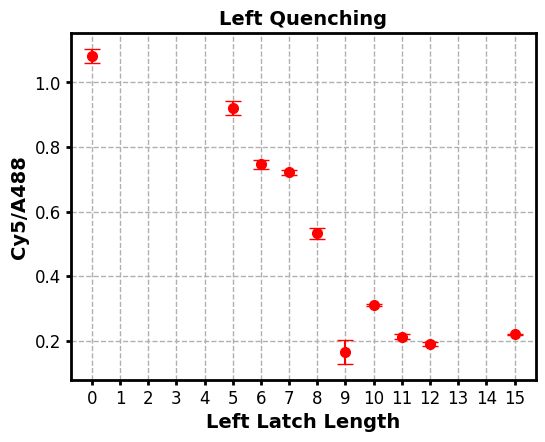

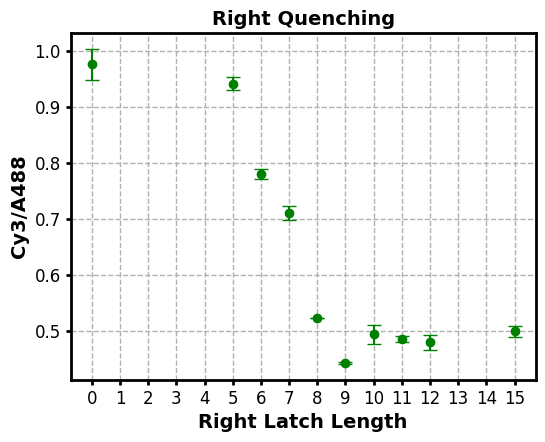

In [ ]:
leftSamples = samples[:10]
rightSamples = samples[10:]
# print(leftSamples, rightSamples)
leftfig, axleft = plt.subplots(figsize=(6, 4.5))
rightfig, axright = plt.subplots(figsize=(6, 4.5))
for sample in leftSamples:
    axleft.errorbar(int(sample.split('_')[0]), normdata[(sample, 'Cy5/A488')].mean(), 
                yerr=normdata[(sample, 'Cy5/A488')].sem(), label=f'Cy5/A488 {sample}', fmt='ro', markersize=7, capsize=6)
axleft.set_title('Left Quenching', fontsize=14, fontweight='bold')
axleft.set_xlabel('Left Latch Length', fontsize=14, fontweight='bold')
axleft.set_ylabel('Cy5/A488', fontsize=14, fontweight='bold')
for sample in rightSamples:
    axright.errorbar(int(sample.split('_')[1].split()[0]), normdata[(sample, 'Cy3/A488')].mean(), 
                yerr=normdata[(sample, 'Cy3/A488')].sem(), label=f'Cy3/A488 {sample}', fmt='go', capsize=5)
axright.set_title('Right Quenching', fontsize=14, fontweight='bold')
axright.set_xlabel('Right Latch Length', fontsize=14, fontweight='bold')
axright.set_ylabel('Cy3/A488', fontsize=14, fontweight='bold')
for ax1 in [axleft, axright]:
    ax1.grid(True, which='both', linestyle='--', linewidth=1)
    ax1.tick_params(axis='both', which='both', width=2, labelsize=12)
    ax1.set_xticks(list(range(16)))
    ax1.spines['left'].set_linewidth(2)
    ax1.spines['bottom'].set_linewidth(2)
    ax1.spines['right'].set_linewidth(2)
    ax1.spines['top'].set_linewidth(2)
leftfig.savefig('left_quenching.png', bbox_inches='tight', dpi=300)
rightfig.savefig('right_quenching.png', bbox_inches='tight', dpi=300)


### Raw plots

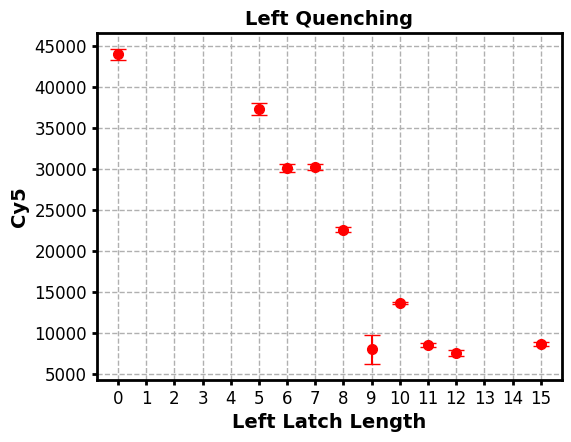

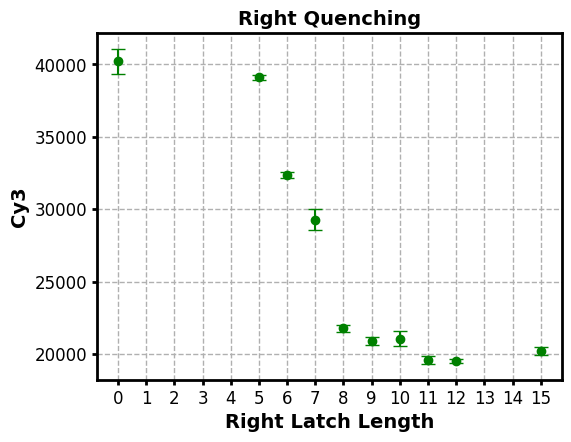

In [6]:
# print(leftSamples, rightSamples)
leftfig, axleft = plt.subplots(figsize=(6, 4.5))
rightfig, axright = plt.subplots(figsize=(6, 4.5))
for sample in leftSamples:
    # ax.errorbar(sample, normdata[(sample, 'Cy3/A488')].mean(), 
    #             yerr=normdata[(sample, 'Cy3/A488')].sem(), label=f'Cy3/A488 {sample}', fmt='go')
    axleft.errorbar(int(sample.split('_')[0]), normdata[(sample, 'Cy5')].mean(), 
                yerr=normdata[(sample, 'Cy5')].sem(), label=f'Cy5 {sample}', fmt='ro', markersize=7, capsize=6)
axleft.set_title('Left Quenching', fontsize=14, fontweight='bold')
axleft.set_xlabel('Left Latch Length', fontsize=14, fontweight='bold')
axleft.set_ylabel('Cy5', fontsize=14, fontweight='bold')
for sample in rightSamples:
    axright.errorbar(int(sample.split('_')[1].split()[0]), normdata[(sample, 'Cy3')].mean(), 
                yerr=normdata[(sample, 'Cy3')].sem(), label=f'Cy3 {sample}', fmt='go', capsize=5)
    # axleft.errorbar(sample, normdata[(sample, 'Cy5')].mean(), 
    #             yerr=normdata[(sample, 'Cy5')].sem(), label=f'Cy5 {sample}', fmt='ro')
axright.set_title('Right Quenching', fontsize=14, fontweight='bold')
axright.set_xlabel('Right Latch Length', fontsize=14, fontweight='bold')
axright.set_ylabel('Cy3', fontsize=14, fontweight='bold')
for ax1 in [axleft, axright]:
    ax1.grid(True, which='both', linestyle='--', linewidth=1)
    ax1.tick_params(axis='both', which='both', width=2, labelsize=12)
    ax1.set_xticks(list(range(16)))
    ax1.spines['left'].set_linewidth(2)
    ax1.spines['bottom'].set_linewidth(2)
    ax1.spines['right'].set_linewidth(2)
    ax1.spines['top'].set_linewidth(2)
leftfig.savefig('raw_left_quenching.png', bbox_inches='tight', dpi=300)
rightfig.savefig('raw_right_quenching.png', bbox_inches='tight', dpi=300)

### A488 Control Plots

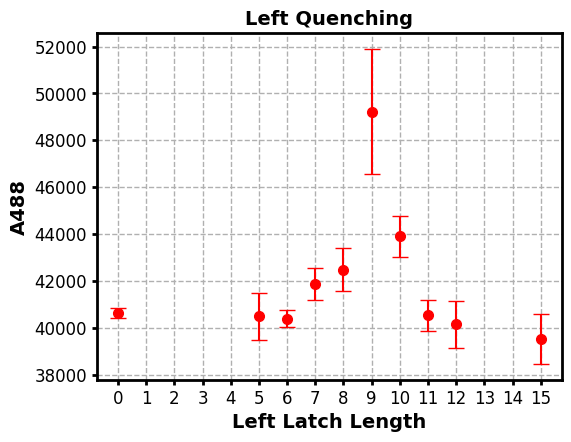

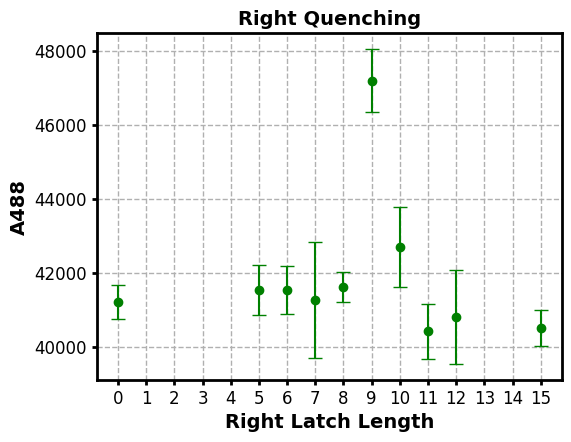

In [7]:
leftfig, axleft = plt.subplots(figsize=(6, 4.5))
rightfig, axright = plt.subplots(figsize=(6, 4.5))
for sample in leftSamples:
    axleft.errorbar(int(sample.split('_')[0]), normdata[(sample, 'A488')].mean(), 
                yerr=normdata[(sample, 'A488')].sem(), label=f'A488 {sample}', fmt='ro', markersize=7, capsize=6)
axleft.set_title('Left Quenching', fontsize=14, fontweight='bold')
axleft.set_xlabel('Left Latch Length', fontsize=14, fontweight='bold')
axleft.set_ylabel('A488', fontsize=14, fontweight='bold')
for sample in rightSamples:
    axright.errorbar(int(sample.split('_')[1].split()[0]), normdata[(sample, 'A488')].mean(), 
                yerr=normdata[(sample, 'A488')].sem(), label=f'A488 {sample}', fmt='go', capsize=5)
axright.set_title('Right Quenching', fontsize=14, fontweight='bold')
axright.set_xlabel('Right Latch Length', fontsize=14, fontweight='bold')
axright.set_ylabel('A488', fontsize=14, fontweight='bold')
for ax1 in [axleft, axright]:
    ax1.grid(True, which='both', linestyle='--', linewidth=1)
    ax1.tick_params(axis='both', which='both', width=2, labelsize=12)
    ax1.set_xticks(list(range(16)))
    ax1.spines['left'].set_linewidth(2)
    ax1.spines['bottom'].set_linewidth(2)
    ax1.spines['right'].set_linewidth(2)
    ax1.spines['top'].set_linewidth(2)
leftfig.savefig('raw_left_A488.png', bbox_inches='tight', dpi=300)
rightfig.savefig('raw_right_A488.png', bbox_inches='tight', dpi=300)